09_NÃO SUPERVISIONADO
          │
          ↓
   Carregar os dados
          │
          ↓
   Carregar embeddings
          │
          ↓
      K-Means
       K = 2
          │
          ↓
    Criar grupos
          │
          ↓
  Avaliar agrupamento
          │
          ↓
 Silhouette Score
          │
          ↓
       PCA
          │
          ↓
 Visualizar os grupos
          │
          ↓
Comparar grupos × target
          │
          ↓
     INTERPRETAÇÃO

Carregar os dados preparados

In [2]:
# Importa a biblioteca joblib, utilizada para carregar o arquivo com os dados preparados.
import joblib

# Carrega os dados preparados para o experimento com Embeddings.
dados_preparados = joblib.load("../data/processed/dados_preparados_embb.joblib")

# Mostra o tipo do objeto carregado para entender sua estrutura.
type(dados_preparados)

dict

Verificar as estruturas disponíveis

In [3]:
# Mostra as chaves disponíveis dentro do dicionário de dados preparados.
dados_preparados.keys()

dict_keys(['X_treino_embb', 'X_teste_embb', 'y_treino', 'y_teste', 'modelo_embedding'])

| Chave              | O que representa                          |
| ------------------ | ----------------------------------------- |
| `X_treino_embb`    | Embeddings das mensagens de treinamento   |
| `X_teste_embb`     | Embeddings das mensagens de teste         |
| `y_treino`         | Rótulos das mensagens de treinamento      |
| `y_teste`          | Rótulos das mensagens de teste            |
| `modelo_embedding` | Modelo utilizado para gerar os embeddings |


Separar os embeddings

In [4]:
# Seleciona os embeddings das mensagens de treinamento para serem utilizados no agrupamento.
embeddings_treino = dados_preparados["X_treino_embb"]

In [5]:
# Mostra a quantidade de mensagens e a quantidade de dimensões dos embeddings.
embeddings_treino.shape

(1077, 408)

Preparar o K-Means

In [7]:
# Importa o StandardScaler para normalizar os atributos antes do agrupamento.
from sklearn.preprocessing import StandardScaler

# Cria o objeto responsável pela normalização dos dados.
normalizador = StandardScaler()

# Normaliza os 408 atributos das mensagens de treinamento.
X_normalizado = normalizador.fit_transform(embeddings_treino)

# Exibe o formato dos dados após a normalização.
X_normalizado.shape

(1077, 408)

Criar o K-Means com 2 grupos

In [8]:
# Importa o algoritmo K-Means para realizar o agrupamento das mensagens.
from sklearn.cluster import KMeans

# Cria o modelo K-Means solicitando a criação de 2 grupos.
modelo_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Treina o K-Means utilizando os 408 atributos normalizados.
modelo_kmeans.fit(X_normalizado)

# Obtém o grupo atribuído pelo K-Means para cada mensagem.
clusters = modelo_kmeans.labels_

# Exibe os grupos atribuídos às mensagens.
clusters

array([1, 1, 1, ..., 1, 1, 1], shape=(1077,), dtype=int32)

Contar as mensagens por grupo

In [9]:
# Importa a função bincount para contar quantas vezes cada grupo aparece.
import numpy as np

# Conta a quantidade de mensagens pertencentes a cada grupo.
quantidade_por_cluster = np.bincount(clusters)

# Exibe a quantidade de mensagens em cada grupo.
quantidade_por_cluster

array([404, 673])

Silhouette Score

O Silhouette Score varia de -1 a 1:

|          Valor | Interpretação                   |
| -------------: | ------------------------------- |
| próximo de `1` | Grupos muito bem separados      |
| próximo de `0` | Grupos pouco separados          |
|       negativo | Possível agrupamento inadequado |


In [10]:
# Importa a métrica Silhouette Score para avaliar a qualidade dos agrupamentos.
from sklearn.metrics import silhouette_score

# Calcula o Silhouette Score utilizando os 408 atributos normalizados e os grupos encontrados.
silhouette = silhouette_score(X_normalizado, clusters)

# Exibe o valor do Silhouette Score.
silhouette

0.0762627193849686

| Silhouette Score | Interpretação                      |
| ---------------: | ---------------------------------- |
| Próximo de **1** | 🟢 Grupos muito bem separados      |
|    **0,5 – 1,0** | Boa separação                      |
|   **0,25 – 0,5** | Separação moderada                 |
|     **0 – 0,25** | 🔴 Separação fraca                 |
|              < 0 | 🔴 Possível agrupamento inadequado |


0,0763 → separação fraca entre os grupos.

Vamos comparar:

Grupo 0
   ↓
Possível golpe = 0 × 1

Grupo 1
   ↓
Possível golpe = 0 × 1

In [12]:
# Importa a biblioteca Pandas para manipulação e análise dos dados.
import pandas as pd

# Cria uma tabela cruzando os grupos encontrados pelo K-Means com o target original.
tabela_clusters = pd.crosstab(clusters, dados_preparados["y_treino"])

# Renomeia as colunas para facilitar a interpretação dos resultados.
tabela_clusters.columns = ["Não golpe", "possível_golpe"]

# Renomeia o índice para identificar os grupos encontrados pelo K-Means.
tabela_clusters.index = ["Grupo 0", "Grupo 1"]

# Exibe a quantidade de mensagens de cada classe dentro de cada grupo.
tabela_clusters

,Não golpe,possível_golpe
Grupo 0,342,62
Grupo 1,324,349


Pureza dos clusters

In [13]:
# Calcula a quantidade total de mensagens em cada grupo.
total_por_cluster = tabela_clusters.sum(axis=1)

# Obtém a maior quantidade de mensagens de uma classe dentro de cada grupo.
maior_classe_por_cluster = tabela_clusters.max(axis=1)

# Calcula a pureza de cada grupo.
pureza_por_cluster = maior_classe_por_cluster / total_por_cluster

# Calcula a pureza geral considerando todos os grupos.
pureza_geral = maior_classe_por_cluster.sum() / total_por_cluster.sum()

# Exibe a pureza de cada grupo.
pureza_por_cluster

Grupo 0    0.846535
Grupo 1    0.518574
dtype: float64

Pureza geral

In [14]:
# Exibe a pureza geral dos agrupamentos encontrados pelo K-Means.
pureza_geral

np.float64(0.6415970287836583)

Juntar treino + teste (usar 100% dataset)

In [15]:
# Combina os atributos das mensagens de treinamento e de teste.
X_completo = np.vstack([dados_preparados["X_treino_embb"], dados_preparados["X_teste_embb"]])

# Combina os targets de treinamento e de teste para permitir a análise posterior dos clusters.
y_completo = np.concatenate([dados_preparados["y_treino"], dados_preparados["y_teste"]])

# Exibe o formato da matriz completa de atributos.
X_completo.shape

(1347, 408)

Normalizar os dados completos

In [16]:
# Cria o normalizador que será utilizado para padronizar os 408 atributos.
normalizador_completo = StandardScaler()

# Normaliza todos os 408 atributos das 1.347 mensagens.
X_completo_normalizado = normalizador_completo.fit_transform(X_completo)

# Exibe o formato dos dados após a normalização.
X_completo_normalizado.shape

(1347, 408)

Agora vamos executar novamente o K-Means, dessa vez usando todo o dataset.

In [17]:
# Cria o modelo K-Means com dois grupos.
modelo_kmeans_completo = KMeans(n_clusters=2, random_state=42, n_init=10)

# Treina o K-Means utilizando as 1.347 mensagens e seus 408 atributos normalizados.
modelo_kmeans_completo.fit(X_completo_normalizado)

# Obtém o grupo atribuído para cada uma das 1.347 mensagens.
clusters_completo = modelo_kmeans_completo.labels_

# Exibe a quantidade de mensagens em cada grupo.
np.bincount(clusters_completo)

array([840, 507])

Silhouette Score

In [18]:
# Calcula o Silhouette Score para avaliar a qualidade dos dois agrupamentos.
silhouette_completo = silhouette_score(X_completo_normalizado, clusters_completo)

# Exibe o resultado do Silhouette Score.
silhouette_completo

0.07556479312831771

cruzar clusters × target

In [19]:
# Cria uma tabela cruzando os grupos encontrados pelo K-Means com o target original.
tabela_clusters_completo = pd.crosstab(clusters_completo, y_completo)

# Renomeia as colunas para facilitar a interpretação.
tabela_clusters_completo.columns = ["Não golpe", "Possível golpe"]

# Renomeia os grupos encontrados pelo K-Means.
tabela_clusters_completo.index = ["Grupo 0", "Grupo 1"]

# Exibe a distribuição das classes dentro de cada grupo.
tabela_clusters_completo

,Não golpe,Possível golpe
Grupo 0,405,435
Grupo 1,428,79


Calcular a pureza

In [20]:
# Calcula o total de mensagens existentes em cada grupo.
total_por_cluster_completo = tabela_clusters_completo.sum(axis=1)

# Identifica a classe predominante em cada grupo.
maior_classe_por_cluster_completo = tabela_clusters_completo.max(axis=1)

# Calcula a pureza de cada grupo.
pureza_por_cluster_completo = maior_classe_por_cluster_completo / total_por_cluster_completo

# Calcula a pureza geral considerando os dois grupos.
pureza_geral_completa = maior_classe_por_cluster_completo.sum() / total_por_cluster_completo.sum()

# Exibe a pureza de cada grupo.
pureza_por_cluster_completo

Grupo 0    0.517857
Grupo 1    0.844181
dtype: float64

Pureza geral

In [21]:
# Exibe a pureza geral dos dois agrupamentos encontrados pelo K-Means.
pureza_geral_completa

np.float64(0.6406829992576095)

Como interpretar a pureza geral?

A pureza de 64,07% significa que, considerando a classe predominante em cada cluster, aproximadamente 64% das mensagens pertencem à classe predominante do seu respectivo grupo.

Mas cuidado: isso não é uma acurácia do K-Means. Estamos usando o Possivel golpe apenas para interpretar os clusters depois que eles foram criados.

PCA (Principal Component Analysis)

PCA é uma técnica de redução de dimensionalidade que transforma várias características originais em novos componentes que preservam o máximo possível da variabilidade dos dados, permitindo representar dados de alta dimensão em poucas dimensões e facilitando sua visualização.

O PCA não altera o resultado do K-Means que já calculamos. Ele será usado apenas para criar uma representação visual dos dados.

Utilizamos PCA para reduzir os 408 atributos para dois componentes principais e visualizar os grupos encontrados pelo K-Means.

In [22]:
# Importa o PCA para reduzir a dimensionalidade dos dados.
from sklearn.decomposition import PCA

# Cria o PCA solicitando a redução dos 408 atributos para 2 componentes principais.
pca = PCA(n_components=2, random_state=42)

# Reduz os 408 atributos normalizados para duas dimensões.
X_pca = pca.fit_transform(X_completo_normalizado)

# Exibe o formato dos dados após a redução de dimensionalidade.
X_pca.shape

(1347, 2)

Variância explicada pelo PCA

In [23]:
# Obtém a proporção da variância explicada pelo primeiro componente principal.
variancia_componente_1 = pca.explained_variance_ratio_[0]

# Obtém a proporção da variância explicada pelo segundo componente principal.
variancia_componente_2 = pca.explained_variance_ratio_[1]

# Soma a variância explicada pelos dois componentes principais.
variancia_total = pca.explained_variance_ratio_.sum()

# Exibe a variância explicada pelo primeiro componente.
print(f"Componente 1: {variancia_componente_1:.2%}")

# Exibe a variância explicada pelo segundo componente.
print(f"Componente 2: {variancia_componente_2:.2%}")

# Exibe a variância total explicada pelos dois componentes.
print(f"Total: {variancia_total:.2%}")

Componente 1: 8.94%
Componente 2: 5.91%
Total: 14.85%


Visualizar os clusters

Vamos criar um gráfico usando:

eixo X → Componente 1
eixo Y → Componente 2
agrupamento → Grupo 0 e Grupo 1

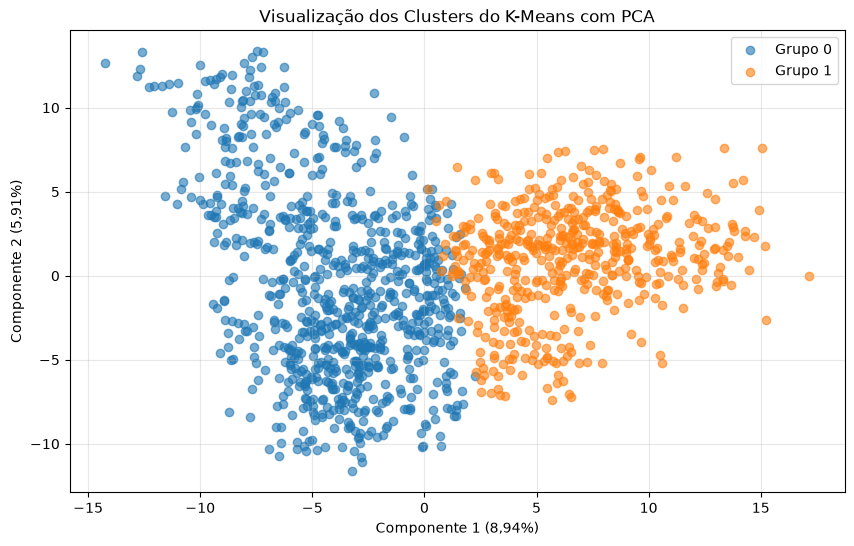

In [24]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Cria uma figura para visualizar os dois componentes principais.
plt.figure(figsize=(10, 6))

# Plota as mensagens pertencentes ao Grupo 0.
plt.scatter(X_pca[clusters_completo == 0, 0], X_pca[clusters_completo == 0, 1], label="Grupo 0", alpha=0.6)

# Plota as mensagens pertencentes ao Grupo 1.
plt.scatter(X_pca[clusters_completo == 1, 0], X_pca[clusters_completo == 1, 1], label="Grupo 1", alpha=0.6)

# Define o nome do eixo horizontal.
plt.xlabel("Componente 1 (8,94%)")

# Define o nome do eixo vertical.
plt.ylabel("Componente 2 (5,91%)")

# Define o título do gráfico.
plt.title("Visualização dos Clusters do K-Means com PCA")

# Exibe a legenda indicando cada grupo.
plt.legend()

# Adiciona uma grade para facilitar a leitura do gráfico.
plt.grid(True, alpha=0.3)

# Exibe o gráfico.
plt.show()

DADOS
  ↓
Transformação das características
  ↓
CLUSTERS
  ↓
┌───────────────────────┐
│ Avaliação dos grupos  │
├───────────────────────┤
│ Silhouette Score      │
│ Pureza dos grupos     │
│ Pureza geral          │
└───────────────────────┘
  ↓
PCA
  ↓
Visualização dos clusters

In [26]:
# Cria a lista com os nomes das 24 features estruturadas utilizadas no projeto.
features_estruturadas = [
    "solicita_senha",
    "solicita_codigo_autenticacao",
    "solicita_dados_bancarios",
    "solicita_dados_pessoais",
    "solicita_dados_cartao",
    "solicita_atualizacao_cadastro",
    "solicita_pagamento",
    "solicita_clique",
    "solicita_ligacao",
    "menciona_bloqueio_conta",
    "carga_emocional",
    "possui_urgencia",
    "possui_ameaca",
    "possui_linguagem_alarmista",
    "possui_recompensa",
    "possui_reembolso",
    "possui_vantagem_inesperada",
    "possui_oferta_financeira",
    "possui_url",
    "possui_url_encurtada",
    "possui_telefone",
    "possui_pix",
    "possui_erros_ortografia_gramatica",
    "possui_chamada_acao"
]

# Exibe a quantidade de features estruturadas.
len(features_estruturadas)

24

Comparar as features entre os clusters

In [27]:
# Importa a biblioteca Pandas para organizar os resultados.
import pandas as pd

# Seleciona as 24 últimas colunas, correspondentes às features estruturadas.
X_features_estruturadas = X_completo_normalizado[:, -24:]

# Cria um DataFrame com as features estruturadas.
df_features_clusters = pd.DataFrame(
    X_features_estruturadas,
    columns=features_estruturadas
)

# Adiciona o cluster encontrado pelo K-Means para cada mensagem.
df_features_clusters["Cluster"] = clusters_completo

# Calcula a média de cada feature dentro de cada cluster.
media_features_por_cluster = df_features_clusters.groupby(
    "Cluster"
).mean()

# Transpõe a tabela para facilitar a comparação entre os grupos.
media_features_por_cluster.T

Cluster,0,1
solicita_senha,0.083615,-0.138534
solicita_codigo_autenticacao,0.202267,-0.335118
solicita_dados_bancarios,0.022222,-0.036817
solicita_dados_pessoais,0.081380,-0.134831
solicita_dados_cartao,0.098582,-0.163330
solicita_atualizacao_cadastro,0.122260,-0.202560
solicita_pagamento,0.160650,-0.266166
solicita_clique,0.313076,-0.518706
solicita_ligacao,0.106538,-0.176513
menciona_bloqueio_conta,0.218038,-0.361246
